This is a note for pre-**ML process** ~

## Os and File Operation

建立路径[./dataclass/sourse]的函数：

In [1]:
import os
PROJECT_ROOT_DIR = "." # 相对路径
def create_dir(data_class,sourse_id): # data_class 为图片/数据/输出/模型等
    aim_path = os.path.join(PROJECT_ROOT_DIR, data_class, sourse_id)
    if not os.path.isdir(aim_path):
        os.makedirs(aim_path)
        print("Dir ["+aim_path+"] has been made!\n")
    else:
        print("Dir ["+aim_path+"] already exists!\n")
    return aim_path #返回建立的路径


保存图片到路径[./image/sourse/xxx.png]的函数：

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
def save_fig(sourse_id, fig_id, tight_layout=True, fig_extension="png", resolution=300):
    IMAGES_PATH=create_dir("image",sourse_id) # 用上述函数新建一个图片种类的路径，提供一个次级分类
    full_path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension) # 图片文件完整路径
    print("Saving figure ["+fig_id+"] in ["+IMAGES_PATH+"]!\n")
    if tight_layout:
        plt.tight_layout()
    plt.savefig(full_path, format=fig_extension, dpi=resolution) # pyplot的保存功能，需要先生成图像
    print("Yah! Figure ["+full_path+"] has been saved!")

## Pandas DataFrame Basis

Download data into dir[./data/xxx]:

In [3]:
import tarfile
import urllib.request

def fetch_tgz_data(housing_url,data_type,data_name):
    data_path=create_dir('data',data_type) # 子路径
    tgz_path = os.path.join(data_path, data_name+'.tgz') # 全路径
    urllib.request.urlretrieve(housing_url, tgz_path) # 下载
    print("["+tgz_path+"] has been downloaded!\n")
    housing_tgz = tarfile.open(tgz_path) # 打开压缩文件
    housing_tgz.extractall(path=data_path) # 解压
    housing_tgz.close()
    print("["+tgz_path+"] has been extracted!\n")
    return (data_path) # 子路径

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"# 服务器中的文件路径
DATA_TYPE='housing_data'
DATA_NAME='housing'

HOUSING_PATH=fetch_tgz_data(HOUSING_URL,DATA_TYPE,DATA_NAME)
print(HOUSING_PATH)


Dir [./data/housing_data] already exists!

[./data/housing_data/housing.tgz] has been downloaded!

[./data/housing_data/housing.tgz] has been extracted!

./data/housing_data


/var/folders/0r/w4xk_f1s0yjbn38ffy83cvj00000gn/T/ipykernel_60137/2827982076.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=data_path) # 解压


Open the .csv file into **DataFrame** object:

In [4]:
import pandas as pd
HOUSING_CSV_PATH=HOUSING_PATH+'/'+DATA_NAME+'.csv'
def load_csv(csv_path):
    print("Yes! Loading "+csv_path+" into pd_DataFrame!\n")
    return pd.read_csv(csv_path)
housing=load_csv(HOUSING_CSV_PATH) # housing是一个pd_DF对象

Yes! Loading ./data/housing_data/housing.csv into pd_DataFrame!



Preview data:
- Use `vb_name.head()` to get first few rows
- Use `vb_name.info()` to get columns info
- Use `vb_name.describe()` to check numerical aspects of each columns(values_type)

In [5]:
housing.head() 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Get Columns:

In [8]:
selected_housing=housing[["median_income","median_house_value"]]
selected_housing_drop=housing.drop("median_house_value",axis=1) # 去除aim项

Get Rows:

In [9]:
selected_housing_rows=housing.loc[[0,1,2,3,4,5]] # 获取前几行
selected_housing_empty=housing[housing.isnull().any(axis=1)] # 有缺陷行, 207行; axis=1指按行进行空白搜索，返回的是有空单元的行

Reshape Data:

In [10]:
NEW_COL=pd.cut(housing["median_house_value"],bins=5,labels=[1,2,3,4,5])
print(NEW_COL) # 搞出一个新的列表储存每一行所属区间，见可视化部分
appended_housing=housing.copy()
appended_housing['NEL_COL']=NEW_COL # 将新列表导入dataframe的新列
appended_housing.head()

0        5
1        4
2        4
3        4
4        4
        ..
20635    1
20636    1
20637    1
20638    1
20639    1
Name: median_house_value, Length: 20640, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,NEL_COL
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,4
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,4
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,4


## Use Matplotlib to Visualize

In [11]:
''' 数据名字备忘
selected_housing: 收入+房价
selected_housing_drop: 去除了房价项
selected_housing_rows: 前5行
selected_housing_empty: 空白行
appended_housing
'''
mpl.rc('axes', labelsize=14) # axis font size
mpl.rc('xtick', labelsize=12)# x,y-label font size
mpl.rc('ytick', labelsize=12) # 全局图片生成样式设置

Create histograms of **numerical** columns:

Dir [./image/housing] already exists!

Saving figure [attribute_histogram_plots] in [./image/housing]!

Yah! Figure [./image/housing/attribute_histogram_plots.png] has been saved!


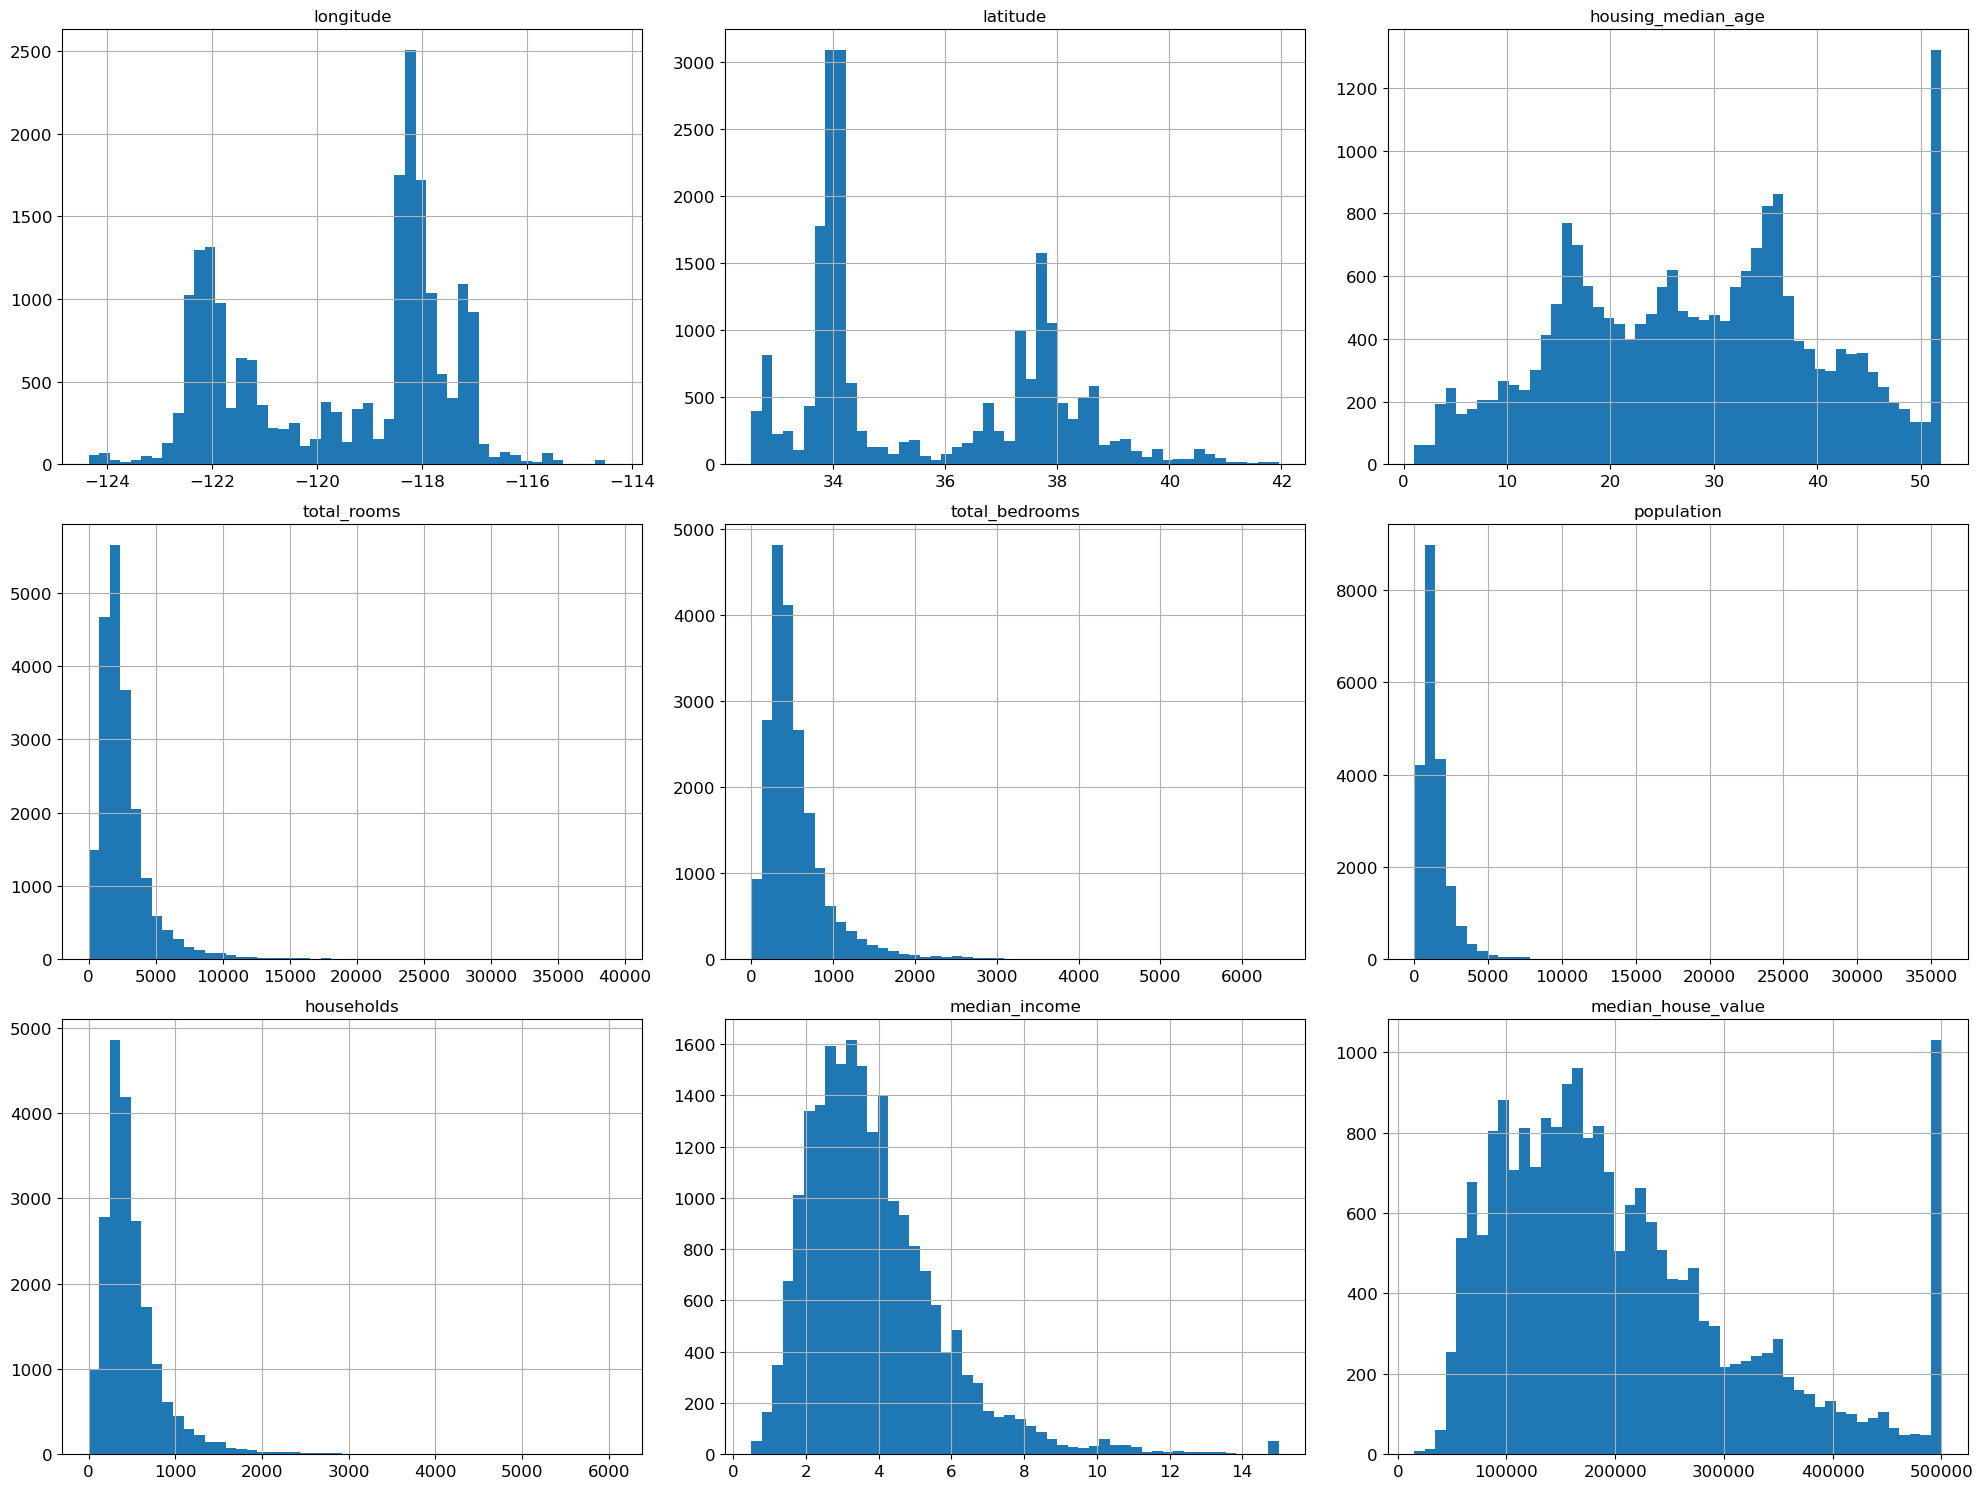

In [12]:
%matplotlib inline 
fig_data_source='housing' # 图片文件的次级分类
housing.hist(bins=50, figsize=(20,15)) # for each col, plot histogram of 50 bins
save_fig(fig_data_source,"attribute_histogram_plots") 
plt.show() # Note: plt.show() will clear the plot



Quickly create figures with 4 dim:
- s is scatter_size
- c is color

Dir [./image/housing] already exists!

Saving figure [4_attribute_scatter_plot] in [./image/housing]!

Yah! Figure [./image/housing/4_attribute_scatter_plot.png] has been saved!


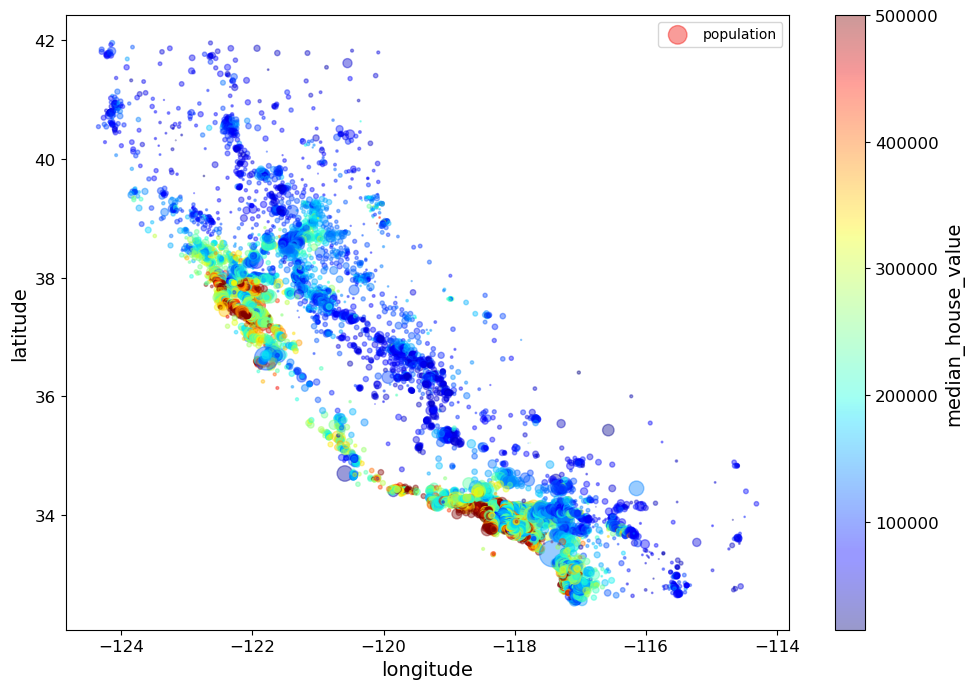

In [13]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=housing["population"]/100, label="population", figsize=(10,7), # 人口表示为点大小
    c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True, sharex=False) # 房价表示为颜色，用jet映射
plt.legend() # 添加图例
save_fig(fig_data_source,'4_attribute_scatter_plot')

## Use sklearn to Clean Data

Split Data into text and number:

In [43]:
import sklearn
try:
    del selected_housing, selected_housing_rows,
    selected_housing_empty,appended_housing
except:
    print("Nothing need to be done!")

label=housing["median_house_value"]
housing_num=selected_housing_drop.drop("ocean_proximity",axis=1)
housing_text=selected_housing_drop["ocean_proximity"] # List

Nothing need to be done!


Now we want to:
- fill blank units with medium value
- sdd attributes of (col1/col2)
- scale the values to std
- One Hot Encode the text list


For the first, we have `SimpleImputer(strategy="median")` from `sklearn.impute`;


In [24]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")
#imputer.fit(housing_num) #会改变本身！

For the second, we need to customize a **transformer**;

In [48]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
class DevideCombineAttributes(BaseEstimator,TransformerMixin):
    def __init__(self,col1,col2,Pd=False) -> None:
        self.col1=col1 # col1，2是需要相除的两列的字符串
        self.col2=col2
        self.Pd=Pd
    def fit(self,X,y=None):
        print("Nothing I can do!\n")
        return self
    def transform(self,Data): # X是DataFrame
        col1_ix= Data.columns.get_loc(self.col1)
        col2_ix= Data.columns.get_loc(self.col2)
        X=Data.values
        devided_list = X[:, col1_ix] / X[:, col2_ix] # 索引到列
        Y=np.c_[X, devided_list] # 按列拼接
        if self.Pd==True:
            return pd.DataFrame(
                Y,
                columns=list(Data)+[self.col1+" per "+self.col2],
                index=Data.index) # 返回仍是DataFrame
        else:
            return Y

Have a little test:

In [51]:
dv_test=DevideCombineAttributes("total_rooms","households",Pd=True)
housing_num_added=dv_test.transform(housing_num)
housing_num_added.head()

array([[-122.23      ,   37.88      ,   41.        , ...,  126.        ,
           8.3252    ,    6.98412698],
       [-122.22      ,   37.86      ,   21.        , ..., 1138.        ,
           8.3014    ,    6.23813708],
       [-122.24      ,   37.85      ,   52.        , ...,  177.        ,
           7.2574    ,    8.28813559],
       ...,
       [-121.22      ,   39.43      ,   17.        , ...,  433.        ,
           1.7       ,    5.20554273],
       [-121.32      ,   39.43      ,   18.        , ...,  349.        ,
           1.8672    ,    5.32951289],
       [-121.24      ,   39.37      ,   16.        , ...,  530.        ,
           2.3886    ,    5.25471698]])

For the rest, use `sklern.preprocessing`;


To combine encoded text(typically a matrix) with number, use `ColumnTransformer()` from `sklearn.compose`.

## Use Pipelines to Connect All

Use this to avoid NumpyArray-DataFrame problem:

In [65]:
class ArrayDataTransformer(BaseEstimator, TransformerMixin):
    def __init__(self,BAD_CLASS): # 传入一个类 SimpleImputer(strategy='median')
        self.bad_class=BAD_CLASS
    def fit(self, X, y=None):
        return self
    def transform(self, Data):
        #try:
        Y=self.bad_class.fit_transform(Data)
        #except:
            #Y=self.bad_class.fit(Data)
        return pd.DataFrame(
                Y,
                columns=list(Data),
                index=Data.index) # 传入需是Dataframe，返回仍是DataFrame


Now build a pipeline for numbers, then combine it with another:

In [119]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit


class DevideCombineAttributes(BaseEstimator,TransformerMixin): # 自定义的添加器
    def __init__(self,col1,col2,Pd=False) -> None:
        self.col1=col1 # col1，2是需要相除的列的指数
        self.col2=col2
        self.Pd=Pd
    def fit(self,X,y=None):
        print("Nothing I can do!\n")
        return self
    def transform(self,X): # X是数据
        devided_list = X[:, self.col1] / X[:, self.col2] # 索引到列
        return np.c_[X, devided_list] # 按列拼接

# 以下为分出训练集环节
# housing_tr,housing_ts=train_test_split(housing, test_size=0.2, random_state=42) # 拆分20%
housing["income_cat"] = pd.cut(housing["median_income"], #按income分割并建立新列
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf], # np.inf means infinity
                               labels=[1, 2, 3, 4, 5]) 
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42) # 分层抽样
for train_index, test_index in split.split(housing, housing["income_cat"]):
    housing_tr = housing.loc[train_index]
    housing_ts = housing.loc[test_index]
housing_tr.drop("income_cat",axis=1,inplace=True)
housing_ts.drop("income_cat",axis=1,inplace=True)


In [120]:
# 以下为数据处理环节
housing_label=housing_tr["median_house_value"]
housing_drop=housing_tr.drop("median_house_value",axis=1)
ix1,ix2=housing_drop.columns.get_loc("total_rooms"),housing_drop.columns.get_loc("households")


num_pipeline=Pipeline([ #建立了pipeline的实例
    ('imputer',SimpleImputer(strategy='median')),
    ('devide_comb_adder',DevideCombineAttributes(ix1,ix2)),
    ('std_scaler',StandardScaler()),
])

num_attribs = list(housing_drop.drop("ocean_proximity",axis=1))
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([ # 对不同的列使用不同的transformer
        ("num", num_pipeline, num_attribs), 
        ("cat", OneHotEncoder(), cat_attribs), 
    ])


Now use the pipeline:

In [121]:
housing_prepared = full_pipeline.fit_transform(housing_drop) 

Nothing I can do!



In [122]:
df = pd.DataFrame(housing_prepared)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-0.941350,1.347438,0.027564,0.584777,0.640371,0.732602,0.556286,-0.893647,0.017395,0.0,1.0,0.0,0.0,0.0
1,1.171782,-1.192440,-1.722018,1.261467,0.781561,0.533612,0.721318,1.292168,0.569256,0.0,0.0,0.0,0.0,1.0
2,0.267581,-0.125972,1.220460,-0.469773,-0.545138,-0.674675,-0.524407,-0.525434,-0.018024,0.0,1.0,0.0,0.0,0.0
3,1.221738,-1.351474,-0.370069,-0.348652,-0.036367,-0.467617,-0.037297,-0.865929,-0.595140,0.0,0.0,0.0,0.0,1.0
4,0.437431,-0.635818,-0.131489,0.427179,0.272790,0.374060,0.220898,0.325752,0.251241,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16507,1.251711,-1.220505,-1.165333,1.890456,1.696862,0.543471,1.341519,0.637374,0.466353,1.0,0.0,0.0,0.0,0.0
16508,-0.921368,1.342761,-1.085806,2.468471,2.161816,3.002174,2.451492,-0.557509,0.050362,0.0,1.0,0.0,0.0,0.0
16509,-1.570794,1.310018,1.538566,-0.895802,-0.895679,-0.862013,-0.865118,-0.365475,-0.509240,1.0,0.0,0.0,0.0,0.0
16510,-1.560803,1.249211,-1.165333,0.249005,0.112126,-0.189747,0.010616,0.168261,0.328149,1.0,0.0,0.0,0.0,0.0


## Training

Causally select a model and train it:

In [124]:
# housing_prepared: 纯数组，clean
# housing_label：训练集的目标，clean
# housing_ts：未处理的数据，需要经过处理

from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42) # 定义了一个模型的实例
tree_reg.fit(housing_prepared, housing_label)

housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_label, housing_predictions)
tree_mse


0.0

Cross-Validation:

In [125]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, housing_prepared, housing_label, # 返回ND数组
                         scoring="neg_mean_squared_error", cv=10) # 负均方误差
tree_rmse_scores = np.sqrt(-scores)

In [126]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [73520.85607749 70227.83118572 68277.19691416 71643.6130917
 71285.84345921 69672.43590504 71077.00673078 69299.52585162
 65017.57587215 74284.76555867]
Mean: 70430.66506465498
Standard deviation: 2507.1535714308534


More:

In [127]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=150, random_state=42)
forest_reg.fit(housing_prepared, housing_label)
housing_predictions = forest_reg.predict(housing_prepared)

forest_mse = mean_squared_error(housing_label, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

18252.543533246648

In [128]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_reg, housing_prepared, housing_label,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [51138.99685903 48643.21819018 45788.78137306 50939.83135263
 47373.10672898 49844.9358033  51244.10575883 49015.1862078
 47279.49112247 52951.89146125]
Mean: 49421.95448575281
Standard deviation: 2096.9394867940123


## Fine-Tune